Lese: /Users/justinbolfrey/Documents/OTH/3. Semester /AI/Anwendungsprogramm_Ki/Part_justin/data/processed/sales_2009_2010.csv
--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB
None

--- Fehlende Werte ---
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
Anzahl Stornos: 12326


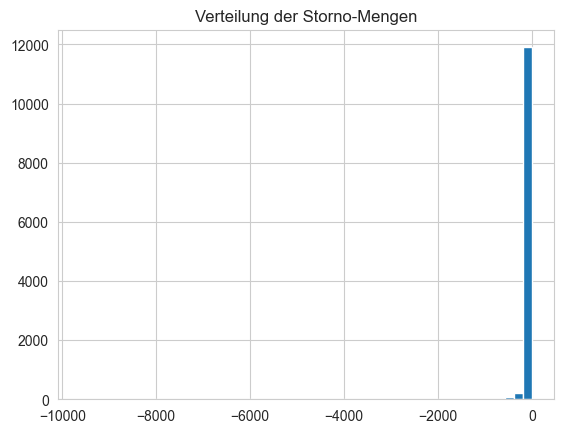

Transaktionen mit negativem Preis (Bad Debt Adjustments):
        Invoice StockCode      Description  Quantity          InvoiceDate  \
179403  A506401         B  Adjust bad debt         1  2010-04-29 13:36:00   
276274  A516228         B  Adjust bad debt         1  2010-07-19 11:24:00   
403472  A528059         B  Adjust bad debt         1  2010-10-20 12:04:00   

           Price  Customer ID         Country  
179403 -53594.36          NaN  United Kingdom  
276274 -44031.79          NaN  United Kingdom  
403472 -38925.87          NaN  United Kingdom  


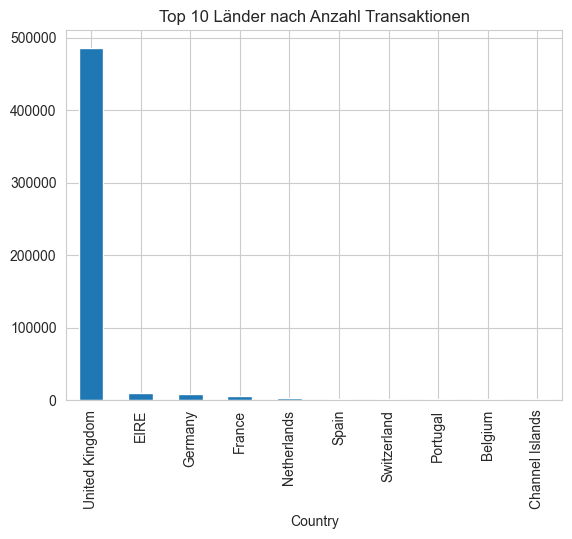

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Config für schönere Charts
sns.set_style("whitegrid")


def get_data_path(filename: str) -> Path:
    """Finde CSV robust, egal ob CWD Repo-Root, Part_justin oder notebooks."""
    here = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
    candidates = [
        here.parent / "data" / "processed" / filename,          # CWD = notebooks
        here / "Part_justin" / "data" / "processed" / filename, # CWD = Repo-Root
        here / "data" / "processed" / filename,                 # CWD = Part_justin
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"CSV nicht gefunden. Probiert: {candidates}")


# 1. Daten laden (Wir nehmen die Raw-CSV zum Vergleich)
data_file = get_data_path("sales_2009_2010.csv")
print(f"Lese: {data_file}")
df = pd.read_csv(data_file)

# 2. Der "Gesundheits-Check"
print("--- Info ---")
print(df.info())
print("\n--- Fehlende Werte ---")
print(df.isnull().sum())

# 3. Analyse der "Stornos" (Wichtig für Business Logic)
# Zeige Verteilung der negativen Mengen
stornos = df[df['Quantity'] < 0]
print(f"Anzahl Stornos: {len(stornos)}")
stornos['Quantity'].hist(bins=50)
plt.title("Verteilung der Storno-Mengen")
plt.show()

# 4. Preis-Analyse
# Gibt es negative Preise?
bad_debt = df[df['Price'] < 0]
print("Transaktionen mit negativem Preis (Bad Debt Adjustments):")
print(bad_debt.head())

# 5. Top Länder (Quick Check)
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='bar')
plt.title("Top 10 Länder nach Anzahl Transaktionen")
plt.show()